In [63]:
import sys
print(sys.executable)

/usr/local/bin/python3


In [64]:
!which python
!which pip

/Users/wolfidy7/miniforge3/bin/python
/Users/wolfidy7/miniforge3/bin/pip


In [65]:
import sys
!{sys.executable} -m pip install pandas pillow imagehash tqdm matplotlib seaborn opencv-python beautifulsoup4 scipy scikit-image


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip


In [ ]:
from bs4 import BeautifulSoup
from collections import Counter
import cv2
import hashlib
import html
import imagehash
import matplotlib.pyplot as plt
import math
import nltk
from nltk.corpus import stopwords
import numpy as np
import os
import pandas as pd
from PIL import Image
import random
import re
import seaborn as sns
import scipy.stats as stats
import textwrap
from tqdm import tqdm
import warnings



warnings.filterwarnings('ignore')

# ETUDE DES IMAGES

## Configuation


In [67]:
IMAGES_PATH = "image_train"
VALID_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

## Recuperation des images

In [68]:
# Nombre max d'images à charger
MAX_IMAGES = None  # mettre None pour tout charger

image_paths = []

files = os.listdir(IMAGES_PATH)

for file in files:

    if file.lower().endswith(VALID_EXTENSIONS):

        full_path = os.path.join(IMAGES_PATH, file)

        # Vérifie que c'est bien un fichier
        if os.path.isfile(full_path):

            image_paths.append(full_path)

            # Stop si limite atteinte
            if MAX_IMAGES is not None and len(image_paths) >= MAX_IMAGES:
                break

print(f"Nombre d'images trouvées : {len(image_paths)}")

Nombre d'images trouvées : 84916


## Structures de stockage

In [69]:
results = []

exact_hashes = {}
perceptual_hashes = {}

duplicate_exact = []
duplicate_visual = []

color_stats = []

corrupted_images = []
blank_images = []
grayscale_images = []

## Fonctions utilitaires

In [70]:
#**Hash exact (fichiers identiques)**
def compute_md5(path):
    with open(path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

## Détection image vides / noires / blanches

In [71]:
def is_blank_image(img, threshold=5):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return np.std(gray) < threshold

In [72]:
#**Détection grayscale**
def is_grayscale(img):
    if len(img.shape) < 3:
        return True

    b, g, r = cv2.split(img)

    return (np.allclose(r, g, atol=2) and np.allclose(g, b, atol=2))

## Analyse principale

In [73]:
for path in tqdm(image_paths):

    try:
        # Chargement image
        img_cv = cv2.imread(path)

        if img_cv is None:
            corrupted_images.append(path)
            continue

        height, width = img_cv.shape[:2]
        ratio = width / height

        # Noir/blanc
        blank = is_blank_image(img_cv)

        if blank:
            blank_images.append(path)

        # grayscale
        gray = is_grayscale(img_cv)

        if gray:
            grayscale_images.append(path)

        # Couleurs moyennes
        mean_b = np.mean(img_cv[:, :, 0])
        mean_g = np.mean(img_cv[:, :, 1])
        mean_r = np.mean(img_cv[:, :, 2])

        color_stats.append([mean_r, mean_g, mean_b])

        # Hash exact
        md5 = compute_md5(path)

        if md5 in exact_hashes:
            duplicate_exact.append((path, exact_hashes[md5]))
        else:
            exact_hashes[md5] = path

        # Hash perceptuel (doublons visuels)
        pil_img = Image.open(path)

        phash = str(imagehash.phash(pil_img))

        if phash in perceptual_hashes:
            duplicate_visual.append((path, perceptual_hashes[phash]))
        else:
            perceptual_hashes[phash] = path

        # Stockage stats
        results.append({
            "path": path,
            "width": width,
            "height": height,
            "ratio": ratio,
            "blank": blank,
            "grayscale": gray
        })

    except Exception as e:
        corrupted_images.append(path)

100%|██████████| 84916/84916 [07:08<00:00, 198.36it/s]


In [74]:
# **DataFrame**
df = pd.DataFrame(results)

print(df.head())

                                                path  width  height  ratio  \
0  image_train/image_1174594490_product_294064072...    500     500    1.0   
1  image_train/image_1172460449_product_185143847...    500     500    1.0   
2  image_train/image_1313553701_product_419925281...    500     500    1.0   
3  image_train/image_1008107210_product_435919430...    500     500    1.0   
4  image_train/image_1190251689_product_273864457...    500     500    1.0   

   blank  grayscale  
0  False      False  
1  False      False  
2  False      False  
3  False      False  
4  False      False  


## Résumé global

In [75]:

def print_image_list(label, paths, max_display=None):
    print(f"\n--- {label} ({len(paths)}) ---")
    items = paths if max_display is None else paths[:max_display]
    for p in items:
        print(f"  {os.path.basename(p)}")
    if max_display and len(paths) > max_display:
        print(f"  ... et {len(paths) - max_display} autres")

print("===== DATASET SUMMARY =====")
print(f"Total images analysées : {len(df)}")
print(f"Images corrompues      : {len(corrupted_images)}")
print(f"Images vides/noires    : {len(blank_images)}")
print(f"Images grayscale       : {len(grayscale_images)}")
print(f"Duplicates exacts      : {len(duplicate_exact)}")
print(f"Duplicates visuels     : {len(duplicate_visual)}")

# if corrupted_images:
#     print_image_list("Images corrompues", corrupted_images)

# if blank_images:
#     print_image_list("Images vides/noires", blank_images)

# if grayscale_images:
#     print_image_list("Images grayscale", grayscale_images)

# if duplicate_exact:
#     print(f"\n--- Duplicates exacts ({len(duplicate_exact)}) ---")
#     for path, original in duplicate_exact:
#         print(f"  {os.path.basename(path)}  <->  {os.path.basename(original)}")

# if duplicate_visual:
#     print(f"\n--- Duplicates visuels ({len(duplicate_visual)}) ---")
#     for path, original in duplicate_visual:
#         print(f"  {os.path.basename(path)}  <->  {os.path.basename(original)}")


===== DATASET SUMMARY =====
Total images analysées : 84916
Images corrompues      : 0
Images vides/noires    : 50
Images grayscale       : 961
Duplicates exacts      : 5692
Duplicates visuels     : 7590


## Visualisation des données (images vides/noires/blanches)

In [76]:
import scipy.stats as stats

# 1. Ajout des statistiques de couleur au DataFrame
# Comme color_stats a été rempli dans la même boucle que results, l'ordre correspond.
df['mean_r'] = [c[0] for c in color_stats]
df['mean_g'] = [c[1] for c in color_stats]
df['mean_b'] = [c[2] for c in color_stats]

# Calcul de l'intensité moyenne globale de l'image (moyenne des 3 canaux)
df['mean_intensity'] = df[['mean_r', 'mean_g', 'mean_b']].mean(axis=1)

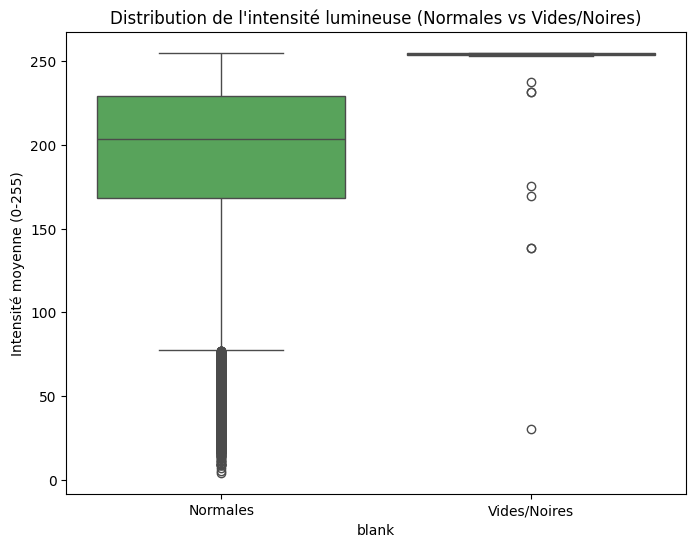

On observe que la répartition de l'intensité lumineuse moyenne des images vides/noires S'ÉCRASE sur des 
valeurs HAUTES (envrion 200-255), ce qui est cohérent avec des images très claires ou blanches (vides).


In [77]:
# 1. Comparaison visuelle de l'intensité moyenne
plt.figure(figsize=(8, 6))
sns.boxplot(x='blank', y='mean_intensity', data=df, palette=['#4CAF50', '#F44336'])
plt.xticks([0, 1], ['Normales', 'Vides/Noires'])
plt.title("Distribution de l'intensité lumineuse (Normales vs Vides/Noires)")
plt.ylabel("Intensité moyenne (0-255)")
plt.show()

print("On observe que la répartition de l'intensité lumineuse moyenne des images vides/noires S'ÉCRASE sur des \nvaleurs HAUTES (envrion 200-255), ce qui est cohérent avec des images très claires ou blanches (vides).")

## Le Test Statistique (Test T de Welch)

Puisque nous voulons comparer les moyennes de deux groupes indépendants ("Images normales" vs "Images vides"), et que ces deux groupes ont des tailles et des variances très différentes (les images noires n'ont quasiment aucune variance, contrairement aux normales), le Test T de Welch (Welch's t-test) est le plus approprié. 

(L'ANOVA ferait la même chose, mais est plutôt conçue pour 3 groupes ou plus).

**Hypothèse Nulle ($H_0$)** : Les images "vides" ont la même intensité moyenne que les images "normales" (la règle de tri n'a aucun sens).

**Hypothèse Alternative ($H_1$)** : Les intensités moyennes sont significativement différentes.

In [78]:
# 2. Séparation des deux échantillons
intensites_normales = df[df['blank'] == False]['mean_intensity']
intensites_vides = df[df['blank'] == True]['mean_intensity']

print(f"Taille de l'échantillon 'Normales' : {len(intensites_normales)}")
print(f"Taille de l'échantillon 'Vides'    : {len(intensites_vides)}")

# On effectue le test seulement s'il y a des images vides
if len(intensites_vides) > 0:
    # Test T de Welch (equal_var=False car les variances sont clairement différentes)
    t_stat, p_value = stats.ttest_ind(intensites_normales, intensites_vides, equal_var=False)
    
    print("\n--- RÉSULTATS DU TEST STATISTIQUE (Test T de Welch) ---")
    print(f"Statistique T : {t_stat:.4f}")
    print(f"P-value       : {p_value:.4e}")
    
    # Interprétation avec un seuil de confiance de 95% (alpha = 0.05)
    alpha = 0.05
    if p_value < alpha:
        print("\nConclusion : La p-value est inférieure à 0.05.")
        print("=> On REJETTE l'hypothèse nulle.")
        print("=> Les images identifiées comme 'vides' ont une distribution de couleurs STATISTIQUEMENT DIFFÉRENTE du reste du dataset. Le filtre est valide !")
    else:
        print("\nConclusion : La p-value est supérieure à 0.05.")
        print("=> On NE PEUT PAS rejeter l'hypothèse nulle.")
        print("=> La différence n'est pas statistiquement significative, le seuil du filtre 'is_blank_image' est peut-être trop large ou inadapté.")
else:
    print("\nAucune image vide/noire détectée, le test statistique n'est pas nécessaire.")

Taille de l'échantillon 'Normales' : 84866
Taille de l'échantillon 'Vides'    : 50

--- RÉSULTATS DU TEST STATISTIQUE (Test T de Welch) ---
Statistique T : -7.7537
P-value       : 4.5214e-10

Conclusion : La p-value est inférieure à 0.05.
=> On REJETTE l'hypothèse nulle.
=> Les images identifiées comme 'vides' ont une distribution de couleurs STATISTIQUEMENT DIFFÉRENTE du reste du dataset. Le filtre est valide !


## Visualisation des données (images similaires/dupliquées)


**Calcul du SSIM et Graphique de stabilité**

Nous allons calculer le SSIM sur un échantillon des doublons visuels et utiliser un Violin Plot (graphique en violon). 

C'est le meilleur choix ici car il combine une boîte à moustaches (pour voir la médiane et les quartiles) 
et une courbe de densité pour visualiser la "stabilité" (la concentration des scores autour de 1).

Calcul du SSIM: 100%|██████████| 150/150 [00:01<00:00, 100.17it/s]


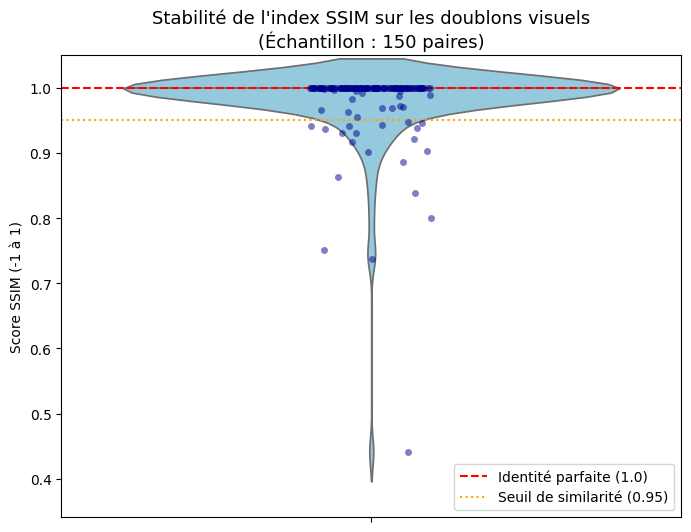

Nous constatons une concentration des scores SSIM autour de 0.95 et plus (surtout autour de 1), ce qui confirme que les images détectées par l'algorithme pHash sont bien quasi-identiques.


In [79]:
import random
from skimage.metrics import structural_similarity as ssim

# **CALCUL DU SSIM SUR LES DOUBLONS VISUELS**

def get_ssim(path1, path2):
    # Lecture en niveaux de gris (recommandé pour le SSIM)
    img1 = cv2.imread(path1, cv2.IMREAD_GRAYSCALE)
    img2 = cv2.imread(path2, cv2.IMREAD_GRAYSCALE)
    
    if img1 is None or img2 is None:
        return None
        
    # Le SSIM nécessite des images de la même dimension
    if img1.shape != img2.shape:
        img2 = cv2.resize(img2, (img1.shape[1], img1.shape[0]))
        
    # Calcul du score (win_size ajusté si les images sont petites)
    min_dim = min(img1.shape)
    win_size = min(7, min_dim) if min_dim < 7 else 7
    
    score, _ = ssim(img1, img2, full=True, win_size=win_size, data_range=255)
    return score

# Échantillonnage pour éviter des temps de calcul trop longs (max 150 paires)
sample_size = min(150, len(duplicate_visual))
sampled_duplicates = random.sample(duplicate_visual, sample_size) if duplicate_visual else []

ssim_scores = []
for p1, p2 in tqdm(sampled_duplicates, desc="Calcul du SSIM"):
    score = get_ssim(p1, p2)
    if score is not None:
        ssim_scores.append(score)

# **VISUALISATION : STABILITÉ DU SSIM**
if ssim_scores:
    plt.figure(figsize=(8, 6))
    
    # Violin plot pour la densité globale
    sns.violinplot(y=ssim_scores, color="skyblue", inner="quartile")
    
    # Strip plot pour voir chaque paire individuellement par-dessus
    sns.stripplot(y=ssim_scores, color="darkblue", alpha=0.5, jitter=True)
    
    plt.axhline(1.0, color='red', linestyle='--', label='Identité parfaite (1.0)')
    plt.axhline(0.95, color='orange', linestyle=':', label='Seuil de similarité (0.95)')
    
    plt.title(f"Stabilité de l'index SSIM sur les doublons visuels\n(Échantillon : {len(ssim_scores)} paires)", fontsize=13)
    plt.ylabel("Score SSIM (-1 à 1)")
    plt.ylim(min(0.5, min(ssim_scores) - 0.1), 1.05)
    plt.legend(loc="lower right")
    plt.show()
else:
    print("Pas assez de données pour calculer le SSIM.")

print("Nous constatons une concentration des scores SSIM autour de 0.95 et plus (surtout autour de 1), ce qui confirme que les images détectées par l'algorithme pHash sont bien quasi-identiques.")

## Test Statistique de Similarité

Nous allons utiliser un Test T pour échantillon unique (One-Sample T-test).

Nous testons l'hypothèse que la vraie moyenne des similarités est très élevée (proche de l'identité).

**Hypothèse Nulle ($H_0$)** : Le SSIM moyen est supérieur ou égal à $0.95$ (Les images sont visuellement identiques/très similaires).

**Hypothèse Alternative ($H_1$)** : Le SSIM moyen est strictement inférieur à $0.95$ (Le filtre pHash a fait des erreurs et a groupé des images trop différentes).

In [80]:
# **TEST STATISTIQUE : VALIDATION DE LA SIMILARITÉ**

if ssim_scores:
    # Seuil de "quasi-identité" visuelle
    threshold = 0.95 
    
    # Test t à un échantillon (alternative='less' car on veut voir si la moyenne est significativement en-dessous du seuil)
    # Note: L'argument alternative nécessite scipy 1.6.0+
    t_stat, p_value = stats.ttest_1samp(ssim_scores, popmean=threshold, alternative='less')
    
    mean_ssim = np.mean(ssim_scores)
    
    print("--- RÉSULTATS DU TEST STATISTIQUE (One-Sample T-Test) ---")
    print(f"Moyenne SSIM de l'échantillon : {mean_ssim:.4f}")
    print(f"Statistique T                 : {t_stat:.4f}")
    print(f"P-value                       : {p_value:.4e}")
    
    alpha = 0.05
    if p_value < alpha:
        print("\nConclusion : La p-value est inférieure à 0.05.")
        print("=> On REJETTE l'hypothèse nulle.")
        print(f"=> Le SSIM moyen est significativement inférieur à {threshold}. Le seuil pHash regroupe des images qui comportent des différences structurelles notables.")
    else:
        print("\nConclusion : La p-value est supérieure à 0.05.")
        print("=> On NE PEUT PAS rejeter l'hypothèse nulle.")
        print(f"=> Statistiquement, le SSIM des doublons est bien concentré à {threshold} ou plus.")
        print("=> Validation : Les images détectées par l'algorithme pHash sont confirmées comme quasi-identiques.")
else:
    print("Pas de données SSIM à tester.")

--- RÉSULTATS DU TEST STATISTIQUE (One-Sample T-Test) ---
Moyenne SSIM de l'échantillon : 0.9808
Statistique T                 : 6.1500
P-value                       : 1.0000e+00

Conclusion : La p-value est supérieure à 0.05.
=> On NE PEUT PAS rejeter l'hypothèse nulle.
=> Statistiquement, le SSIM des doublons est bien concentré à 0.95 ou plus.
=> Validation : Les images détectées par l'algorithme pHash sont confirmées comme quasi-identiques.


# ETUDE TEXTUELLE / CATEGORIELLE

In [6]:
df1 = pd.read_csv('./csv/X_train_update.csv')
df2 = pd.read_csv('./csv/Y_train_CVw08PX.csv')

df = pd.concat([df1, df2], axis=1)
df = df.drop(['Unnamed: 0'], axis=1)
df["image_filename"] = "image_" + df["imageid"].astype(str) + "_product_" + df["productid"].astype(str) + ".jpg"

display(df.info())
df.head(5)

<class 'pandas.DataFrame'>
RangeIndex: 84916 entries, 0 to 84915
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   designation     84916 non-null  str  
 1   description     55116 non-null  str  
 2   productid       84916 non-null  int64
 3   imageid         84916 non-null  int64
 4   prdtypecode     84916 non-null  int64
 5   image_filename  84916 non-null  str  
dtypes: int64(3), str(3)
memory usage: 3.9 MB


None

,designation,description,productid,imageid,prdtypecode,image_filename
0,Olivia: Personalisiertes Notizbuch / 150 Seite...,NaN,3804725264,1263597046,10,image_1263597046_product_3804725264.jpg
1,Journal Des Arts (Le) N° 133 Du 28/09/2001 - L...,NaN,436067568,1008141237,2280,image_1008141237_product_436067568.jpg
2,Grand Stylet Ergonomique Bleu Gamepad Nintendo...,PILOT STYLE Touch Pen de marque Speedlink est ...,201115110,938777978,50,image_938777978_product_201115110.jpg
3,Peluche Donald - Europe - Disneyland 2000 (Mar...,NaN,50418756,457047496,1280,image_457047496_product_50418756.jpg
4,La Guerre Des Tuques,Luc a des id&eacute;es de grandeur. Il veut or...,278535884,1077757786,2705,image_1077757786_product_278535884.jpg


## Quelques chiffres

In [ ]:
# Comptage des lignes / classes
class_counts = df["prdtypecode"].value_counts().sort_values(ascending=False)
print(f"Le dataset contient {len(df)} lignes réparties sur {len(class_counts)} classes différentes.")



def clean_text(x):
    if pd.isna(x):
        return np.nan
    
    x = str(x)
    x = html.unescape(x)
    x = re.sub(r"<[^>]+>", " ", x)  # suppression HTML
    x = re.sub(r"\s+", " ", x).strip()
    
    return x


def stats_colonne_texte(df, col):
    col_clean = f"{col}_clean_tmp"
    
    data = df.copy()
    data[col_clean] = data[col].apply(clean_text)
    
    present = data[col_clean].notna() & (data[col_clean] != "")
    textes = data.loc[present, col_clean]
    
    nb_mots = textes.str.findall(r"\b\w+\b").str.len()
    
    value_counts = textes.value_counts()
    
    # Groupby seulement sur les textes présents
    grouped = data.loc[present].groupby(col_clean)
    
    stats = {
        "Valeurs manquantes": data[col].isna().sum(),
        "% valeurs manquantes": data[col].isna().mean() * 100,
    
        
        "Nombre médian de mots": nb_mots.median(),
        "Nombre moyen de mots": nb_mots.mean(),
        
        "Textes distincts": textes.nunique(),
        "Textes répétés distincts": (value_counts > 1).sum(),
        "Lignes concernées par un texte répété": textes.duplicated(keep=False).sum(),
        
        "Textes utilisés pour plusieurs produits": (grouped["productid"].nunique() > 1).sum(),
        "Textes utilisés pour plusieurs images": (grouped["imageid"].nunique() > 1).sum(),
        "Textes utilisés dans plusieurs classes": (grouped["prdtypecode"].nunique() > 1).sum(),
        
        "Textes contenant du HTML": data[col].astype(str).str.contains(r"<[^>]+>", na=False).sum(),
    }
    
    return stats


# Tableau comparatif
resume_textes = pd.DataFrame({
    "Désignation": stats_colonne_texte(df, "designation"),
    "Description": stats_colonne_texte(df, "description")
})

# Arrondir les pourcentages et moyennes
resume_textes = resume_textes.round(0).astype(int)

display(resume_textes)
print("_ La désignation est toujours présente et courte, avec une médiane de 11 mots. Elle constitue donc une base textuelle fiable pour tous les produits.")
print()
print("_ À l'inverse, la description est plus riche lorsqu'elle existe, avec une médiane proche de 97 mots, mais elle est absente pour environ 35 % des produits. ")
print("Elle apporte donc davantage de contexte, mais de manière inégale selon les lignes.")
print()
print("_ On observe également des textes répétés, ainsi que quelques désignations ou descriptions associées à plusieurs classes différentes.")
print("Cela montre qu'un même texte peut parfois correspondre à plusieurs types de produits, ce qui peut créer de l'ambiguïté pour le modèle.")
print()
print("_ Les descriptions contiennent aussi un nombre important de balises HTML, ce qui confirme la nécessité d'un nettoyage préalable avant toute vectorisation.")
print()
print("_ Pour la suite du projet, nous choisirons donc de concaténer la désignation et la description dans une seule variable textuelle.")
print("Cette approche permet de conserver la désignation, présente pour tous les produits, tout en ajoutant l'information complémentaire contenue dans la description lorsqu'elle est disponible.")

Le dataset contient 84916 lignes réparties sur 27 classes différentes.


,Désignation,Description
Valeurs manquantes,0,29800
% valeurs manquantes,0,35
Nombre médian de mots,11,97
Nombre moyen de mots,12,126
Textes distincts,82259,47309
Textes répétés distincts,1428,3064
Lignes concernées par un texte répété,4085,10783
Textes utilisés pour plusieurs produits,1428,3064
Textes utilisés pour plusieurs images,1428,3064
Textes utilisés dans plusieurs classes,146,277


_ La désignation est toujours présente et courte, avec une médiane de 11 mots. Elle constitue donc une base textuelle fiable pour tous les produits.

_ À l'inverse, la description est plus riche lorsqu'elle existe, avec une médiane proche de 97 mots, mais elle est absente pour environ 35 % des produits. 
Elle apporte donc davantage de contexte, mais de manière inégale selon les lignes.

_ On observe également des textes répétés, ainsi que quelques désignations ou descriptions associées à plusieurs classes différentes.
Cela montre qu'un même texte peut parfois correspondre à plusieurs types de produits, ce qui peut créer de l'ambiguïté pour le modèle.

_ Les descriptions contiennent aussi un nombre important de balises HTML, ce qui confirme la nécessité d'un nettoyage préalable avant toute vectorisation.

_ Pour la suite du projet, nous choisirons donc de concaténer la désignation et la description dans une seule variable textuelle.
Cette approche permet de conserver la désignation, pré

## Répartition des descriptions manquantes par catégorie

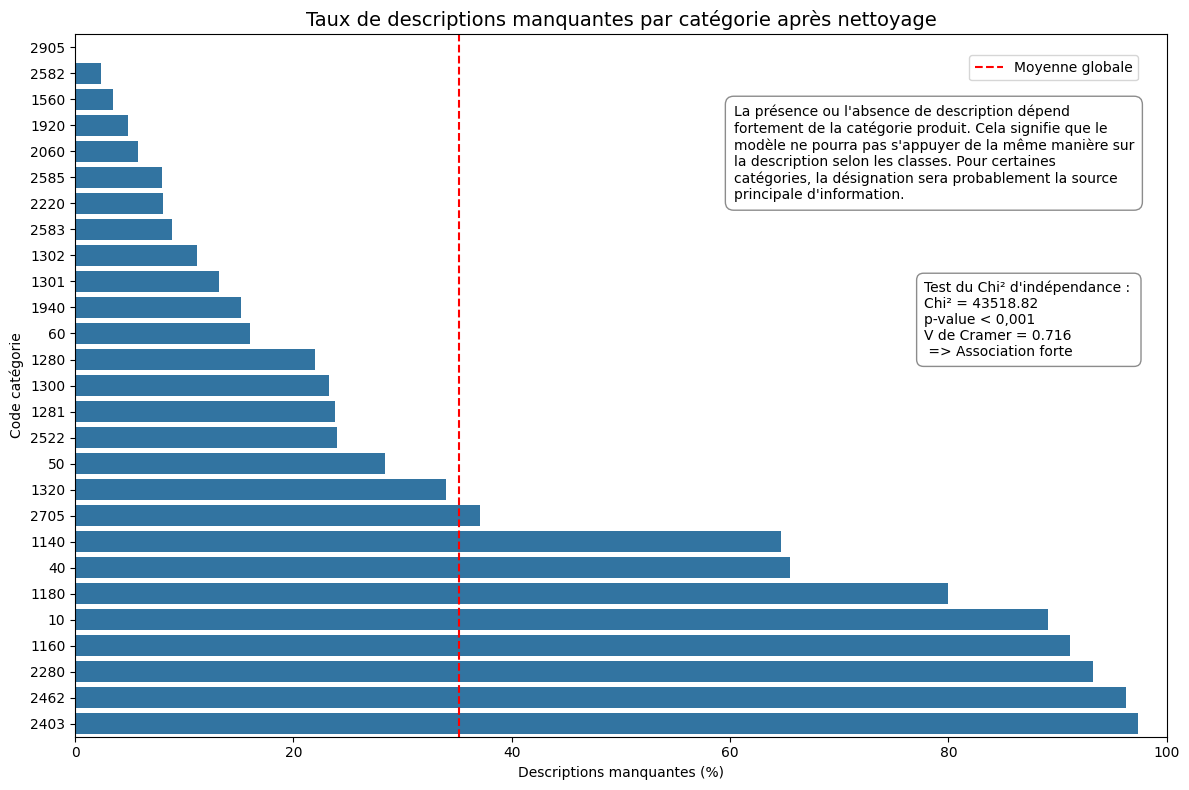

Le test du Chi² compare deux variables qualitatives :


,Variable,Type
0,prdtypecode,catégorie produit
1,description_absente,booléen : description absente ou présente



Hypothèses :
H0 : La catégorie produit et l'absence de description sont indépendantes.
H1 : La catégorie produit et l'absence de description ne sont pas indépendantes.

Un Chi² à 43518.82 est très élevé, ce qui indique un écart important entre les effectifs observés et les effectifs attendus si tout était indépendant
Mais le Chi² seul ne suffit pas à interpréter la force de la dépendance entre les deux variables, surtout avec un grand nombre d'observations.

une p-value à 0.0000e+00, donc non nulle mais très proche de 0, ce qui permet de rejeter l'hypothèse nulle d'indépendance entre les deux variables.

Un V de Cramer à 0.716, donc > à 0.5, indique une association très forte entre la catégorie produit et l'absence de description


In [ ]:
# Nettoyage simple du HTML
def clean_text(x):
    if pd.isna(x):
        return ""
    x = re.sub(r"<[^>]+>", " ", str(x))
    x = html.unescape(x)
    x = re.sub(r"\s+", " ", x)
    return x.strip()

df["designation_clean"] = df["designation"].apply(clean_text)
df["description_clean"] = df["description"].apply(clean_text)

df["description_absente"] = df["description_clean"].eq("")

# Agrégation
desc_missing = (
    df.groupby("prdtypecode")
    .agg(
        nb_produits=("prdtypecode", "size"),
        taux_description_absente=("description_absente", "mean")
    )
    .reset_index()
)

desc_missing["taux_description_absente_pct"] = desc_missing["taux_description_absente"] * 100
desc_missing = desc_missing.sort_values("taux_description_absente_pct")

# Calcul du Chi²
contingence = pd.crosstab(df["prdtypecode"], df["description_absente"])
chi2, p_value, dof, expected = stats.chi2_contingency(contingence)


n = contingence.to_numpy().sum()
v_cramer = math.sqrt(chi2 / (n * (min(contingence.shape) - 1)))

# Graphique
import textwrap

fig, ax = plt.subplots(figsize=(12, 8))

sns.barplot(
    data=desc_missing,
    x="taux_description_absente_pct",
    y=desc_missing["prdtypecode"].astype(str),
    ax=ax
)

ax.axvline(
    df["description_absente"].mean() * 100,
    linestyle="--",
    label="Moyenne globale",
    color="red"
)

ax.set_title("Taux de descriptions manquantes par catégorie après nettoyage", fontsize=14)
ax.set_xlabel("Descriptions manquantes (%)")
ax.set_ylabel("Code catégorie")
ax.set_xlim(0, 100)
ax.legend(
    loc="upper right",
    bbox_to_anchor=(0.98, 0.98),
    frameon=True
)

# Texte interprétation
texte_interpretation = (
    "La présence ou l'absence de description dépend fortement de la catégorie produit. "
    "Cela signifie que le modèle ne pourra pas s'appuyer de la même manière sur la description "
    "selon les classes. Pour certaines catégories, la désignation sera probablement la source "
    "principale d'information."
)

texte_interpretation = textwrap.fill(texte_interpretation, width=55)

# Bulle principale dans le graphique, en haut à droite
ax.text(
    0.97, 0.90,
    texte_interpretation,
    transform=ax.transAxes,
    fontsize=10,
    ha="right",
    va="top",
    multialignment="left",
    bbox=dict(
        boxstyle="round,pad=0.6",
        facecolor="white",
        edgecolor="gray",
        alpha=0.9
    )
)

# Bulle statistique juste en dessous
texte_stats = (
    "Test du Chi² d'indépendance : \n"
    f"Chi² = {chi2:.2f} \n"
    "p-value < 0,001\n"
    f"V de Cramer = {v_cramer:.3f}\n"
    " => Association forte"
)

ax.text(
    0.97, 0.65,
    texte_stats,
    transform=ax.transAxes,
    fontsize=10,
    ha="right",
    va="top",
    multialignment="left",
    bbox=dict(
        boxstyle="round,pad=0.5",
        facecolor="white",
        edgecolor="gray",
        alpha=0.9
    )
)

plt.tight_layout()
plt.show()


# Test du Chi²
print("Le test du Chi² compare deux variables qualitatives :")
display(pd.DataFrame({
    "Variable": ["prdtypecode", "description_absente"],
    "Type": ["catégorie produit", "booléen : description absente ou présente"]
}))

print("\nHypothèses :")
print("H0 : La catégorie produit et l'absence de description sont indépendantes.")
print("H1 : La catégorie produit et l'absence de description ne sont pas indépendantes.")
print()



print(f"Un Chi² à {chi2:.2f} est très élevé, ce qui indique un écart important entre les effectifs observés et les effectifs attendus si tout était indépendant")
print("Mais le Chi² seul ne suffit pas à interpréter la force de la dépendance entre les deux variables, surtout avec un grand nombre d'observations.")
print()
print(f"une p-value à {p_value:.4e}, donc non nulle mais très proche de 0, ce qui permet de rejeter l'hypothèse nulle d'indépendance entre les deux variables.")
print()
print(f"Un V de Cramer à {v_cramer:.3f}, donc > à 0.5, indique une association très forte entre la catégorie produit et l'absence de description")

## Distribution des catégories

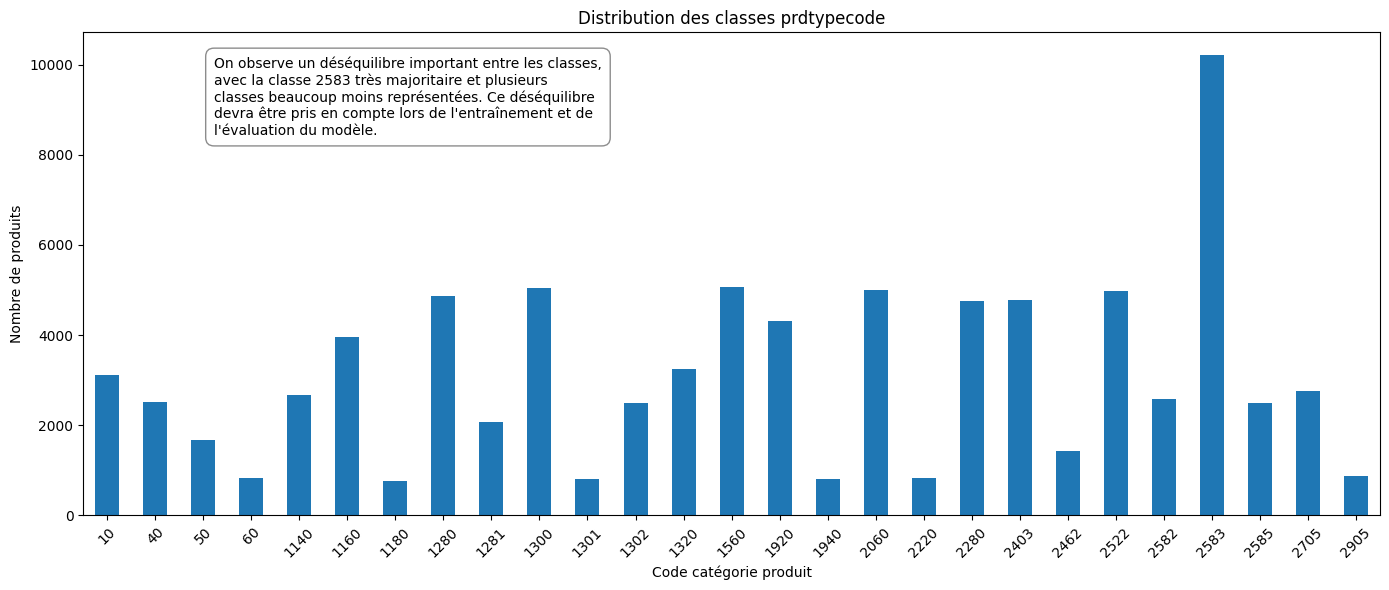

In [47]:
# Comptage des classes
class_counts = df["prdtypecode"].value_counts().sort_index()

# Pourcentage par classe
class_percent = (class_counts / len(df) * 100).round(2)

# Tableau récapitulatif
class_distribution = pd.DataFrame({
    "effectif": class_counts,
    "pourcentage": class_percent
})

# Graphique
fig, ax = plt.subplots(figsize=(14, 6))

class_counts.plot(
    kind="bar",
    ax=ax
)

ax.set_title("Distribution des classes prdtypecode")
ax.set_xlabel("Code catégorie produit")
ax.set_ylabel("Nombre de produits")
ax.tick_params(axis="x", rotation=45)

# Texte interprétation
texte_interpretation = (
    "On observe un déséquilibre important entre les classes, avec la classe 2583 très majoritaire "
    "et plusieurs classes beaucoup moins représentées. Ce déséquilibre devra être pris en compte "
    "lors de l'entraînement et de l'évaluation du modèle."
)

texte_interpretation = textwrap.fill(texte_interpretation, width=55)

# Bulle principale dans le graphique, en haut à droite
ax.text(
    0.40, 0.95,
    texte_interpretation,
    transform=ax.transAxes,
    fontsize=10,
    ha="right",
    va="top",
    multialignment="left",
    bbox=dict(
        boxstyle="round,pad=0.6",
        facecolor="white",
        edgecolor="gray",
        alpha=0.9
    )
)

plt.tight_layout()
plt.show()

## Longueur du texte par catégorie

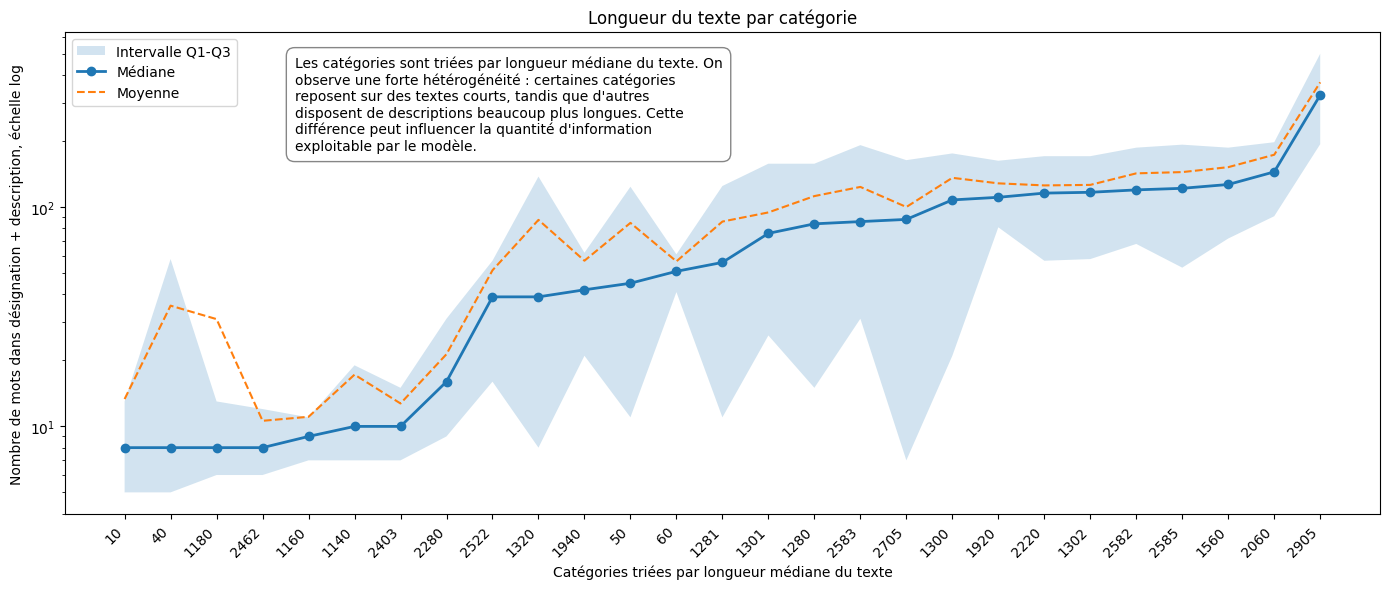

In [ ]:
# Texte complet
df["texte_complet"] = (
    df["designation_clean"].fillna("") + " " + df["description_clean"].fillna("")
).str.strip()

df["nb_mots_texte"] = df["texte_complet"].str.findall(r"\b\w+\b").str.len()

# Statistiques par catégorie
length_stats = (
    df.groupby("prdtypecode")["nb_mots_texte"]
    .agg(
        q1=lambda x: x.quantile(0.25),
        mediane="median",
        q3=lambda x: x.quantile(0.75),
        moyenne="mean",
        nb="size"
    )
    .reset_index()
    .sort_values("mediane")
)

# Positions x
x = np.arange(len(length_stats))

fig, ax = plt.subplots(figsize=(14, 6))

# Zone interquartile Q1-Q3
ax.fill_between(
    x,
    length_stats["q1"],
    length_stats["q3"],
    alpha=0.2,
    label="Intervalle Q1-Q3"
)

# Courbe de la médiane
ax.plot(
    x,
    length_stats["mediane"],
    marker="o",
    linewidth=2,
    label="Médiane"
)

# Optionnel : moyenne en pointillé
ax.plot(
    x,
    length_stats["moyenne"],
    linestyle="--",
    linewidth=1.5,
    label="Moyenne"
)

ax.set_xticks(x)
ax.set_xticklabels(length_stats["prdtypecode"].astype(str), rotation=45, ha="right")

ax.set_yscale("log")

ax.set_title("Longueur du texte par catégorie")
ax.set_xlabel("Catégories triées par longueur médiane du texte")
ax.set_ylabel("Nombre de mots dans désignation + description, échelle log")

# Légende en haut à gauche
ax.legend(loc="upper left")

# Bulle interprétation
texte_interpretation = (
    "Les catégories sont triées par longueur médiane du texte. "
    "On observe une forte hétérogénéité : certaines catégories reposent sur des textes courts, "
    "tandis que d'autres disposent de descriptions beaucoup plus longues. "
    "Cette différence peut influencer la quantité d'information exploitable par le modèle."
)

texte_interpretation = textwrap.fill(texte_interpretation, width=60)

ax.text(
    0.50, 0.95,
    texte_interpretation,
    transform=ax.transAxes,
    fontsize=10,
    ha="right",
    va="top",
    multialignment="left",
    bbox=dict(
        boxstyle="round,pad=0.6",
        facecolor="white",
        edgecolor="gray",
        alpha=0.95
    )
)

plt.tight_layout()
plt.show()